In [66]:
# 0) Reading the data:

import pandas as pd

df = pd.read_csv("../data/transactional-sample.csv")
df.head()

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


In [67]:
# 1) Inicial dataset analysis:
# 1.1) Ensure data integrity:

print(f"rows={len(df)}")
print(f"cols={len(df.columns)}")
print(f"columns={','.join(df.columns)}")

df.info()

# Some device_id are null

rows=3199
cols=8
columns=transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      3199 non-null   int64  
 1   merchant_id         3199 non-null   int64  
 2   user_id             3199 non-null   int64  
 3   card_number         3199 non-null   object 
 4   transaction_date    3199 non-null   object 
 5   transaction_amount  3199 non-null   float64
 6   device_id           2369 non-null   float64
 7   has_cbk             3199 non-null   bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 178.2+ KB


In [68]:
# 1.2) Classes balance:

cbk_counts = df["has_cbk"].astype(str).str.upper().value_counts(dropna=False)
true_count = int(cbk_counts.get("TRUE", 0))
false_count = int(cbk_counts.get("FALSE", 0))
cbk_rate = (true_count / len(df)) * 100 if len(df) else 0.0

print(f"has_cbk_TRUE={true_count}")
print(f"has_cbk_FALSE={false_count}")
print(f"has_cbk_rate_percent={cbk_rate:.2f}")

# The dataset presents a fraud (chargeback) rate of 12.22%, which is significantly high compared to typical payment industry benchmarks.

has_cbk_TRUE=391
has_cbk_FALSE=2808
has_cbk_rate_percent=12.22


In [69]:
# 1.3) Transaction Amount info:

amount_stats = df["transaction_amount"].describe()
print(f"amount_min={amount_stats['min']:.2f}")
print(f"amount_max={amount_stats['max']:.2f}")
print(f"amount_avg={amount_stats['mean']:.2f}")
print(f"amount_sum={df['transaction_amount'].sum():.2f}")
amount_stats

# Transactions range from 1.22 to 4097.21 reais, with an average of 767.81.

amount_min=1.22
amount_max=4097.21
amount_avg=767.81
amount_sum=2456233.48


count    3199.000000
mean      767.812904
std       889.095904
min         1.220000
25%       205.235000
50%       415.940000
75%       981.680000
max      4097.210000
Name: transaction_amount, dtype: float64

In [70]:
# 1.4) Date range info:

date_series = pd.to_datetime(df["transaction_date"], errors="coerce")
print(f"date_min={date_series.min()}")
print(f"date_max={date_series.max()}")
print(f"date_count={date_series.count()}")

# The dataset refers to two full days.

date_min=2019-11-01 01:27:15.811098
date_max=2019-12-01 23:16:32.812632
date_count=3199


In [71]:
# 1.5) Transaction IDs duplication check:

duplicate_transaction_id_rows = int(df["transaction_id"].duplicated().sum())
print(f"duplicate_transaction_id_rows={duplicate_transaction_id_rows}")

# There is no duplicate transaction_id

duplicate_transaction_id_rows=0


In [72]:
# 1.6) merchant_id info, merchants with the most fraudulent sales quantities:

top_merchants = (
    df[df["has_cbk"].astype(str).str.upper() == "TRUE"]["merchant_id"]
    .value_counts()
    .head(5)
)
top_merchants

# The merchants with the highest number of fraudulent sales have a maximum of 22 sales.

merchant_id
17275    22
4705     19
1308     15
53041    14
77130    13
Name: count, dtype: int64

In [73]:
# 1.7) user_id info, users with the most fraudulent transactions quantities:

top_users = (
    df[df["has_cbk"].astype(str).str.upper() == "TRUE"]["user_id"]
    .value_counts()
    .head(5)
)
top_users

# The users with the highest number of fraudulent transactions have a maximum of 25 transactions.

user_id
11750    25
91637    19
79054    15
96025    13
78262    12
Name: count, dtype: int64

In [74]:
# 2) Exploring the dataset, founding suspicious behaviors:

# 2.1) Looking for users with 100% fraud rate:

user_analysis = df.groupby("user_id").agg({
    "has_cbk": ["mean", "count"]
})

user_analysis.columns = ["fraud_rate", "transaction_count"]

user_analysis.sort_values(by="fraud_rate", ascending=False).head(10)

# Several users exhibit a fraud rate of 100%, meaning all their transactions resulted in chargebacks. However, an important distinction must be made: users with only one transaction may represent isolated fraud cases or simply insufficient data, while users with multiple transactions and a 100% fraud rate are significantly more suspicious, indicating consistent fraudulent behavior. For example, some users performed three to four transactions, all of which resulted in chargebacks. This pattern strongly suggests intentional fraud activity and the potential use of stolen credentials or synthetic identities.

,fraud_rate,transaction_count
user_id,,
39334,1.0,1
45031,1.0,1
11065,1.0,4
86219,1.0,1
50699,1.0,1
5541,1.0,3
47604,1.0,2
19820,1.0,3
21233,1.0,2


In [75]:
# 2.2) Looking for device sharing:

device_analysis = df.groupby("device_id").agg({
    "user_id": "nunique",
    "has_cbk": ["mean", "count"]
})

device_analysis.columns = ["unique_users", "fraud_rate", "transaction_count"]

device_analysis.sort_values(by="unique_users", ascending=False).head(10)

# The analysis shows that each device is associated with only one user, indicating no direct evidence of device sharing. However, this does not necessarily imply low fraud risk, as fraudsters often use techniques such as device spoofing or frequently changing devices to avoid detection. Additionally, certain devices show suspicious behavior; for example, some devices are associated with multiple transactions and a 100% fraud rate. This may indicate compromised devices, automated fraud activity, or the repeated use of a device for fraudulent transactions.

,unique_users,fraud_rate,transaction_count
device_id,,,
2.0,1,0.0,1
4.0,1,0.0,1
486.0,1,1.0,4
2359.0,1,0.0,1
2630.0,1,0.0,1
3044.0,1,0.0,1
3290.0,1,0.0,1
4076.0,1,0.0,1
4571.0,1,0.0,2


In [76]:
# 2.3) Looking for users with multiple devices:

user_device_analysis = df.groupby("user_id").agg(
    num_devices=("device_id", "nunique"),
    fraud_rate=("has_cbk", "mean"),
    transaction_count=("has_cbk", "count")
)

user_device_analysis.sort_values(by="num_devices", ascending=False).head(10)

# Several users with two to three devices show a 100% fraud rate across multiple transactions, and one user (11750) stands out with four devices, 31 transactions, and an 80% fraud rate, indicating sustained fraudulent activity. However, some users with multiple devices show no fraud, demonstrating that device count alone is not sufficient to identify fraud.

,num_devices,fraud_rate,transaction_count
user_id,,,
11750,4,0.806452,31
18205,3,0.000000,4
99396,3,1.000000,5
7725,2,1.000000,7
90182,2,0.500000,2
92034,2,0.750000,4
9853,2,0.444444,9
34548,2,0.000000,6
9600,2,1.000000,2


In [77]:
# 2.4) Relation between transaction_amount and fraud:

df.groupby("has_cbk")["transaction_amount"].describe()

# Fraudulent transactions show significantly higher values compared to non-fraudulent ones. The analysis indicates that the average transaction amount for fraud is more than double that of non-fraud, while the median transaction value for fraud is nearly three times higher. High-value transactions are strongly associated with chargebacks, suggesting that fraudsters aim to maximize financial gain when executing fraudulent transactions. Additionally, the presence of low-value fraudulent transactions points to possible card testing behavior before executing larger transactions. This dual pattern, characterized by low-value testing followed by high-value fraud, is a well-known fraud strategy.

,count,mean,std,min,25%,50%,75%,max
has_cbk,,,,,,,,
False,2808.0,672.324380,797.463853,1.22,191.285,360.315,812.5775,4091.83
True,391.0,1453.571918,1169.491346,2.89,565.580,999.470,2140.6800,4097.21


In [78]:
# 2.5) Relation between the missing user_id and fraud:

df["device_missing"] = df["device_id"].isna()

df.groupby("device_missing")["has_cbk"].mean()

# Contrary to expectations, transactions with device information present a higher fraud rate (approximately 13.7%) compared to those without (around 8.1%). This suggests that the presence of device data does not necessarily reduce fraud risk and that fraudulent transactions are still occurring even when devices are identifiable. Possible explanations include the fact that fraudsters may not be actively hiding their devices, or that device tracking systems are more effective at capturing suspicious transactions. This highlights that device identification alone is not sufficient as a fraud prevention mechanism and must be combined with behavioral and transactional analysis

device_missing
False    0.136767
True     0.080723
Name: has_cbk, dtype: float64

In [79]:
# 2.6) Looking for temporal patterns with the fraudulent transactions, first per hour:

# Converter para datetime e extrair hora
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["hour"] = df["transaction_date"].dt.hour

# Calcular taxa de fraude por hora
hour_analysis = df.groupby("hour")["has_cbk"].mean().sort_index()

hour_analysis

# Fraudulent transactions show a clear temporal pattern, with significantly higher fraud rates during late-night and early-morning hours. The analysis indicates that fraud rates peak between 19 p.m and 3 a.m., with elevated activity also observed in 6 a.m (possible anomaly, the next analysis will be the total number of transactions). In contrast, daytime hours, between 4 a.m. and 18 p.m., show very low or near-zero fraud rates (excluding the 6 a.m case). This suggests that fraudulent activity is more frequent outside of typical user behavior patterns. Possible explanations include reduced monitoring during off-hours, the presence of automated fraud attempts, and a lower likelihood of immediate detection. Therefore, the time of transaction is a strong feature for fraud detection and should be incorporated into risk scoring models.

hour
0     0.180451
1     0.126126
2     0.295082
3     0.133333
4     0.000000
5     0.000000
6     0.500000
8     0.000000
9     0.000000
10    0.000000
11    0.053763
12    0.081081
13    0.056410
14    0.064777
15    0.075314
16    0.107914
17    0.114391
18    0.082734
19    0.167939
20    0.136029
21    0.185022
22    0.177914
23    0.198864
Name: has_cbk, dtype: float64

<Axes: title={'center': 'Fraud Rate by Hour'}, xlabel='hour'>

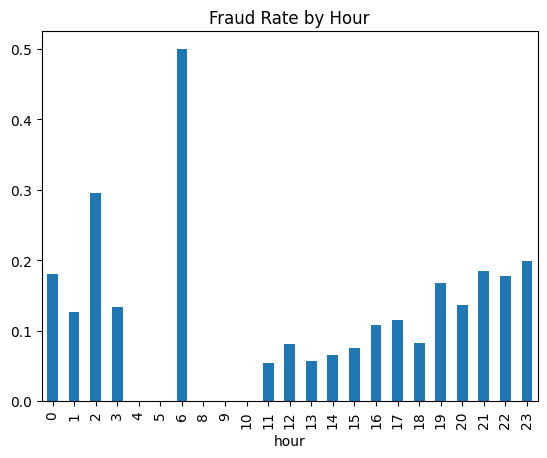

In [80]:
# 2.6) Graphic Visualization

hour_analysis.plot(kind="bar", title="Fraud Rate by Hour")

In [81]:
# 2.7) Incorporating the quantity of fraud transactions into the temporal analysis:

hour_stats = df.groupby("hour").agg(
    total_transactions=("has_cbk", "count"),
    fraud_rate=("has_cbk", "mean"),
    fraud_count=("has_cbk", "sum")
).sort_index()

hour_stats

# When considering both fraud rate and transaction volume, the most critical risk period occurs during evening hours (19h–23h). During this time, relatively high fraud rates, ranging from 17% to 20%, are combined with large transaction volumes, resulting in the highest absolute number of fraudulent transactions. In contrast, late-night hours between midnight and 3 a.m. exhibit high fraud rates but lower transaction volumes. Additionally, some early-morning spikes, such as around 6 a.m., are not statistically significant due to very low transaction counts, while daytime hours consistently show lower fraud rates, reflecting more typical user behavior. This analysis highlights that fraud is most impactful during high-volume periods rather than just high-percentage periods, and reinforces that time of transaction should be incorporated into fraud risk scoring, with higher risk assigned to evening hours.

,total_transactions,fraud_rate,fraud_count
hour,,,
0,133,0.180451,24
1,111,0.126126,14
2,61,0.295082,18
3,30,0.133333,4
4,7,0.000000,0
5,4,0.000000,0
6,2,0.500000,1
8,3,0.000000,0
9,7,0.000000,0


<Axes: title={'center': 'Fraud Count by Hour'}, xlabel='hour'>

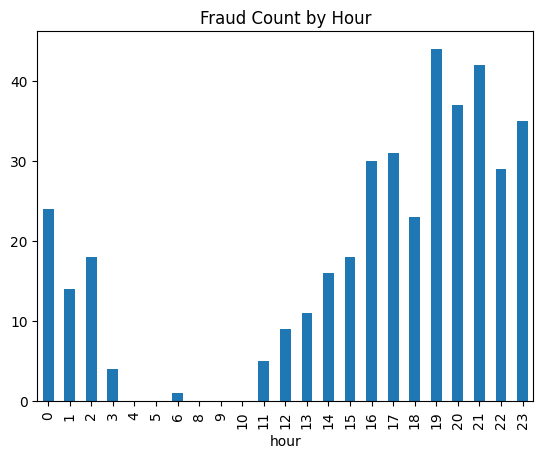

In [82]:
# 2.7) Graphic Visualization

fraud_count_by_hour = df.groupby("hour")["has_cbk"].sum()

fraud_count_by_hour.plot(kind="bar", title="Fraud Count by Hour")

In [83]:
# 2.8) Incorporating the transaction_amount into the temporal analysis:

hour_value_analysis = df.groupby("hour").agg(
    total_transactions=("transaction_amount", "count"),
    fraud_rate=("has_cbk", "mean"),
    fraud_count=("has_cbk", "sum"),
    total_amount=("transaction_amount", "sum"),
    fraud_amount=("transaction_amount", lambda x: x[df.loc[x.index, "has_cbk"]].sum())
).sort_index()

hour_value_analysis

# The financial impact of fraud is highly concentrated during late afternoon and evening hours (16h–23h). The analysis shows that the highest monetary losses occur between 16h and 23h, with a peak at 19h, where fraudulent transactions exceed R$74,000. These hours combine high transaction volume, elevated fraud rates, and high-value transactions, making them particularly critical. In contrast, early-morning hours present high fraud rates but result in significantly lower financial impact. This demonstrates that fraud risk should be evaluated not only by frequency but also by financial exposure, and that the most critical risk window occurs during periods of high volume and high-value transactions. Targeting fraud prevention efforts during these hours could significantly reduce financial losses.

,total_transactions,fraud_rate,fraud_count,total_amount,fraud_amount
hour,,,,,
0,133,0.180451,24,80564.63,26162.51
1,111,0.126126,14,78655.19,16822.33
2,61,0.295082,18,54393.12,27028.89
3,30,0.133333,4,15044.57,5821.73
4,7,0.000000,0,2595.26,0.00
5,4,0.000000,0,1700.23,0.00
6,2,0.500000,1,265.23,263.93
8,3,0.000000,0,1676.79,0.00
9,7,0.000000,0,1729.59,0.00


<Axes: title={'center': 'Fraud Amount by Hour'}, xlabel='hour'>

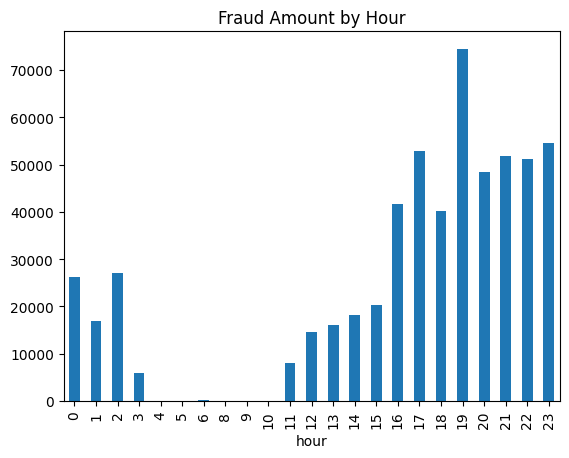

In [84]:
# 2.8) Graphic Visualization

hour_value_analysis["fraud_amount"].plot(
    kind="bar",
    title="Fraud Amount by Hour"
)

In [88]:
# 2.9) Quantity of merchants with 100% of fraudulent transactions:

merchant_fraud = df.groupby("merchant_id")["has_cbk"].agg(["sum", "count"])

merchants_100 = merchant_fraud[merchant_fraud["sum"] == merchant_fraud["count"]]

num_merchants_100 = len(merchants_100)

num_merchants_100

# There is 66 merchants with only fraudulent transactions

66

In [86]:
# 2.9) Relation between merchant_id and total fraud transactions:

fraud_per_merchant = df.groupby("merchant_id")["has_cbk"].sum()

fraud_per_merchant_sorted = fraud_per_merchant.sort_values(ascending=False)

cumulative_fraud = fraud_per_merchant_sorted.cumsum()
total_fraud = fraud_per_merchant_sorted.sum()

cumulative_percentage = cumulative_fraud / total_fraud * 100

merchant_concentration = pd.DataFrame({
    "fraud_count": fraud_per_merchant_sorted,
    "cumulative_fraud": cumulative_fraud,
    "cumulative_percentage": cumulative_percentage
})

num_merchants_80 = (merchant_concentration["cumulative_percentage"] <= 80).sum()
total_merchants = len(merchant_concentration)

print(f"\nMerchants responsible for 80% of fraud: {num_merchants_80}")
print(f"Total merchants: {total_merchants}")
print(f"Merchants percentual: {num_merchants_80 / total_merchants:.2%}")

# The distribution of fraud across merchants is highly concentrated. The analysis shows that only 52 merchants, representing just 2.96% of the total, are responsible for 80% of all fraudulent transactions, while the vast majority of merchants exhibit little to no fraudulent activity. This indicates a strong concentration of fraud within a very small subset of merchants and reinforces that fraud is not randomly distributed across the merchant base. As a result, targeted interventions focused on high-risk merchants can significantly reduce overall fraud, and concentrating efforts on this small group has the potential to generate reduction in financial losses.


Merchants responsible for 80% of fraud: 52
Total merchants: 1756
Merchants percentual: 2.96%


In [ ]:
### Key Findings

# - Fraud rate is high (~12%), indicating a high-risk environment
# - Fraud is highly concentrated: ~3% of merchants generate 80% of fraud
# - Fraud is strongly associated with high transaction values
# - Evening hours (19h–23h) concentrate the highest financial losses
# - Multi-device behavior combined with high fraud rates is a strong indicator of suspicious activity